# Praca domowa III: Klasyfikacja Obrazów CIFAR-10 przy użyciu Sieci Konwolucyjnych (CNN)
**Cel projektu:** Zbudowanie od podstaw architektury sieci neuronowej w bibliotece PyTorch w celu klasyfikacji 10 kategorii obiektów. Projekt obejmuje analizę danych (EDA), budowę modelu, badanie wpływu hiperparametrów (Learning Rate, Batch Size, Kernel Size, Pooling) oraz wybór optymalnego modelu za pomocą metody Grid Search.

## 1. Importowanie bibliotek i konfiguracja środowiska
W poniższej komórce ładujemy niezbędne biblioteki oraz sprawdzamy dostępność akceleracji sprzętowej (GPU/CUDA), która znacząco przyspieszy proces uczenia modelu.

In [2]:
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import itertools


torch.manual_seed(46)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Używam urządzenia: {device}")

Używam urządzenia: cuda


## 2. Analiza Eksploracyjna Danych (EDA)
Zanim przejdziemy do budowy modelu, sprawdzimy podstawowe statystyki zbioru CIFAR-10. Zweryfikujemy rozkład klas (aby upewnić się, że zbiór jest zbalansowany) oraz wyświetlimy galerię przykładowych zdjęć w oryginalnej rozdzielczości 32x32 pikseli, aby zrozumieć, z jak trudnym zadaniem zmierzy się nasza sieć.

C:\Users\Kamil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Całkowita liczba obrazów treningowych: 50000
Wymiary pojedynczego obrazuL: (32, 32, 3) (Wysokość x Szerokość x 3 kanały RGB)
Zakres wartości pikseli: od 0 do 255 (Standardowy 8-bitowy format RGB
)


C:\Users\Kamil\AppData\Local\Temp\ipykernel_10324\2956486738.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette='viridis')


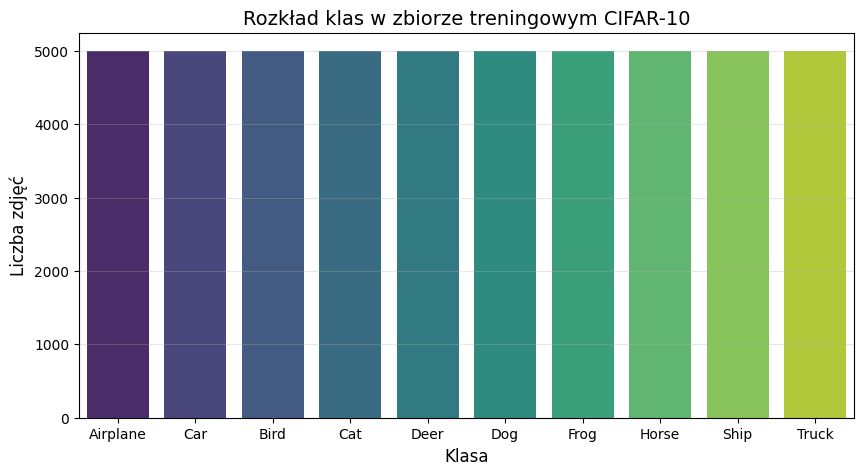

Wniosek: Zbiór CIFAR-10 jest idealnie zbalansowany. Każda z 10 klas posiada dokładnie 5000 zdjęć treningowych, co eliminuje problem faworyzowania klas przez model (class imbalance).

--- PRZYKŁADOWE OBRAZY ZE ZBIORU ---


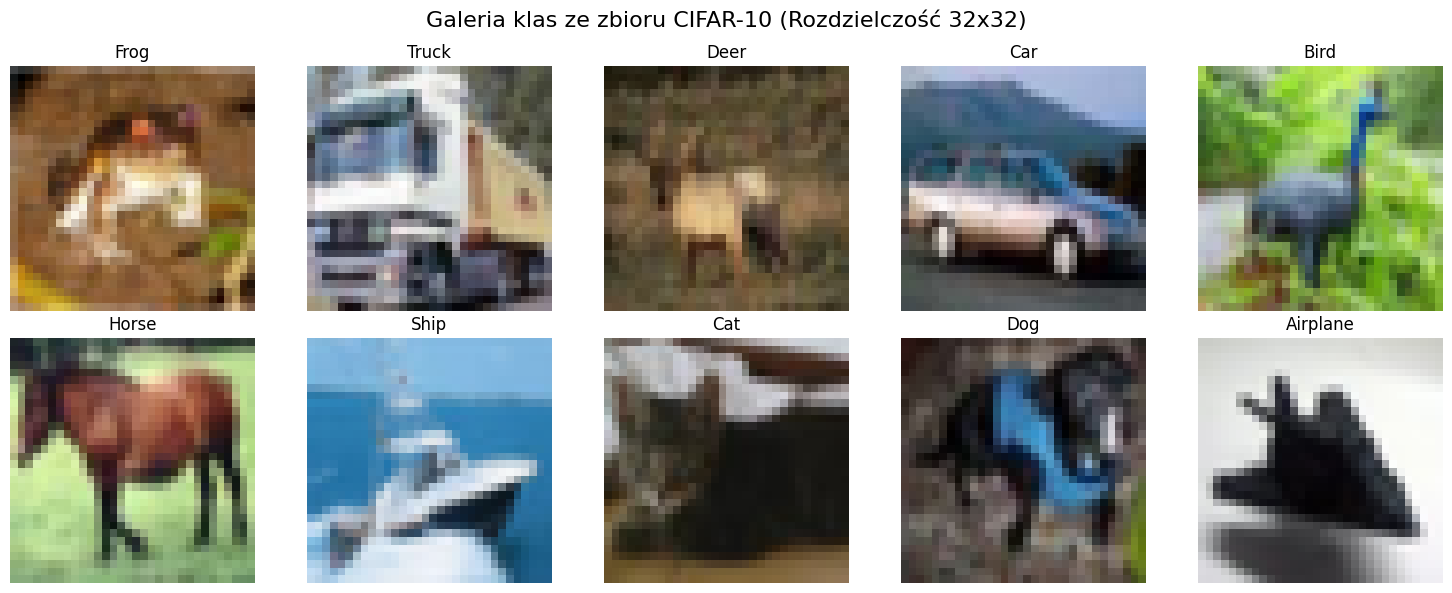

In [4]:
train_data_raw = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
class_names = ['Airplane', 'Car', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

print(f'Całkowita liczba obrazów treningowych: {len(train_data_raw)}')

random_pic, label = train_data_raw[0]
img_array = np.array(random_pic)

print(f'Wymiary pojedynczego obrazuL: {img_array.shape} (Wysokość x Szerokość x 3 kanały RGB)')
print(f'Zakres wartości pikseli: od {img_array.min()} do {img_array.max()} (Standardowy 8-bitowy format RGB\n)')

class_counts = {name: 0 for name in class_names}
for _, labell in train_data_raw:
    class_counts[class_names[labell]] += 1

plt.figure(figsize=(10,5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette='viridis')
plt.title('Rozkład klas w zbiorze treningowym CIFAR-10', fontsize=14)
plt.xlabel('Klasa', fontsize=12)
plt.ylabel('Liczba zdjęć', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()


print("Wniosek: Zbiór CIFAR-10 jest idealnie zbalansowany. Każda z 10 klas posiada dokładnie 5000" \
" zdjęć treningowych, co eliminuje problem faworyzowania klas przez model (class imbalance).")

print("\n--- PRZYKŁADOWE OBRAZY ZE ZBIORU ---")
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Galeria klas ze zbioru CIFAR-10 (Rozdzielczość 32x32)', fontsize=16)

found_classes = set()
i = 0
while len(found_classes) < 10:
    img, label = train_data_raw[i]
    if label not in found_classes:
        row = len(found_classes)//5
        col = len(found_classes)%5
        ax = axes[row, col]
        ax.imshow(img)
        ax.set_title(class_names[label])
        ax.axis('off')
        found_classes.add(label)
    i += 1

plt.tight_layout()
plt.show()

## 3. Definicja Architektury Sieci Konwolucyjnej
Sercem projektu jest uniwersalna funkcja `CNN`, która automatyzuje cały potok uczenia maszynowego (wczytanie danych, budowę modelu, trening i ewaluację). 

**Architektura modelu:**
Zaprojektowano sieć złożoną z dwóch warstw konwolucyjnych (wyciągających cechy z obrazu) oraz dwóch warstw w pełni połączonych (klasyfikatora). Funkcja została napisana w sposób dynamiczny, pozwalający na łatwą zmianę parametrów w trakcie eksperymentów, w tym automatyczne przeliczanie wymiarów tensorów w zależności od wybranej metody poolingu (Max, Avg lub brak poolingu).

In [2]:
def CNN(batch_size_test=16, learning_rate=0.1, kernel_size=3, pooling='max', epochs=5, verbose=True):
    transformation = transforms.ToTensor()
    training_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transformation)
    test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transformation)

    train_loader = DataLoader(training_set, batch_size=batch_size_test, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=batch_size_test, shuffle=False)

    if verbose: print(f'Downloaded {len(training_set)} images')


    if pooling == 'max':
        pool_layer = nn.MaxPool2d(kernel_size=2)
        linear_input = 2048
    elif pooling == 'avg':
        pool_layer = nn.AvgPool2d(kernel_size=2)
        linear_input = 2048
    elif pooling == 'none':
        pool_layer = nn.Identity()
        linear_input = 32768
    else:
        raise ValueError('Zły typ poolingu!')
    
    model = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=16, kernel_size=kernel_size, padding=kernel_size//2),
        nn.ReLU(),
        pool_layer,
        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=kernel_size, padding=kernel_size//2),
        nn.ReLU(),
        pool_layer,
        nn.Flatten(),
        nn.Linear(linear_input, 128),
        nn.ReLU(),
        nn.Linear(128, 10)
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimalization = optim.Adam(model.parameters(), lr=learning_rate)
    history_loss = []

    for epoch in range(epochs):
        model.train()
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimalization.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimalization.step()

        history_loss.append(loss.item())
        if verbose:
            print(f"Epoka {epoch+1}/{epochs} | Błąd (Loss): {loss.item():.4f}")

    model.eval()
    all_guesses = []
    real_results = []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            diag_test = model(x)
            _, pred = torch.max(diag_test.data, 1)
            all_guesses.extend(pred.cpu().numpy())
            real_results.extend(y.numpy())

    acc = accuracy_score(real_results, all_guesses)
    prec = precision_score(real_results, all_guesses, average='macro', zero_division=0)
    recall = recall_score(real_results, all_guesses, average='macro', zero_division=0)
    f1 = f1_score(real_results, all_guesses, average='macro', zero_division=0)
    matrix = confusion_matrix(real_results, all_guesses)

    return history_loss, acc, model, matrix, prec, recall, f1

## 4. Opis architektury, warstw i uzasadnienie hiperparametrów

### Architektura sieci
Zastosowana sieć neuronowa to klasyczna architektura konwolucyjna (CNN), zaprojektowana do ekstrakcji hierarchicznych cech z obrazów o niskiej rozdzielczości (32x32). Składa się ona z dwóch bloków konwolucyjnych oraz klasyfikatora w pełni połączonego (Dense).

**Struktura warstw:**
1. **Warstwa konwolucyjna (Conv2d - 16 filtrów):** Pierwsza warstwa "skanuje" obraz w poszukiwaniu podstawowych wzorców, takich jak krawędzie czy proste kolory.
2. **ReLU (Activation):** Funkcja aktywacji wprowadzająca nieliniowość (zeruje wartości ujemne), co pozwala sieci uczyć się złożonych zależności.
3. **Pooling (Max/Avg):** Warstwa redukcji wymiarowości. Zmniejsza rozmiar obrazu o połowę, zachowując najważniejsze informacje (np. najmocniejszy sygnał w danym obszarze).
4. **Warstwa konwolucyjna (Conv2d - 32 filtry):** Druga warstwa łączy proste krawędzie w bardziej złożone kształty (np. oczy, koła, uszy).
5. **Flatten:** Przekształca dwuwymiarowe mapy cech na jeden długi wektor, przygotowując dane dla klasyfikatora.
6. **Warstwy Linear (Gęste):** Pierwsza warstwa (128 neuronów) łączy wszystkie wykryte cechy w abstrakcyjną wiedzę, a ostatnia warstwa (10 neuronów) wyznacza prawdopodobieństwo przynależności obrazu do jednej z 10 klas CIFAR-10.

### Uzasadnienie wyboru hiperparametrów
Wybór końcowych parametrów nie był przypadkowy i został poparty serią eksperymentów:

* **Learning Rate (0.001):** Eksperymenty wykazały, że jest to "złoty środek". Wyższe wartości (0.01, 0.1) powodowały zbyt gwałtowne zmiany wag (oscylacje), natomiast niższe (0.0001) uczyły sieć zbyt wolno, nie osiągając zadowalającego poziomu w 5 epokach.
* **Batch Size (64):** Wartość ta zapewnia optymalny kompromis między stabilnością uczenia (wygładzanie szumu w gradiencie) a szybkością obliczeń na karcie graficznej.
* **Kernel Size (3x3):** Jest to standard w nowoczesnych sieciach. Mały filtr pozwala na budowanie głębokich struktur przy mniejszej liczbie parametrów, co ogranicza ryzyko przeuczenia (overfittingu) przy tak małych zdjęciach.
* **Pooling (MaxPool):** Wybrano MaxPool, ponieważ lepiej niż AvgPool radzi sobie z selekcją najbardziej istotnych cech wizualnych, co potwierdziły wyniki Grid Search.

## 5. Eksperymenty - Badanie wpływu pojedynczych hiperparametrów
Zgodnie z poleceniem, przeprowadzono serie eksperymentów, zmieniając tylko jeden parametr naraz i "zamrażając" pozostałe na optymalnych, domyślnych wartościach.

### Seria 1: Wpływ współczynnika uczenia (Learning Rate)
Sprawdzamy, jak wielkość kroku optymalizatora Adam wpływa na szybkość i stabilność zbiegania funkcji straty.


Testing Learning Rate: 0.0001


C:\Users\Kamil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Downloaded 50000 images
Epoka 1/5 | Błąd (Loss): 1.9086
Epoka 2/5 | Błąd (Loss): 1.4866
Epoka 3/5 | Błąd (Loss): 1.7252
Epoka 4/5 | Błąd (Loss): 1.4832
Epoka 5/5 | Błąd (Loss): 1.6244

Testing Learning Rate: 0.001


C:\Users\Kamil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Downloaded 50000 images
Epoka 1/5 | Błąd (Loss): 1.2126
Epoka 2/5 | Błąd (Loss): 1.0968
Epoka 3/5 | Błąd (Loss): 1.2006
Epoka 4/5 | Błąd (Loss): 1.3276
Epoka 5/5 | Błąd (Loss): 0.9127

Testing Learning Rate: 0.01


C:\Users\Kamil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Downloaded 50000 images
Epoka 1/5 | Błąd (Loss): 1.4094
Epoka 2/5 | Błąd (Loss): 1.2189
Epoka 3/5 | Błąd (Loss): 1.5744
Epoka 4/5 | Błąd (Loss): 1.5800
Epoka 5/5 | Błąd (Loss): 1.1213

Testing Learning Rate: 0.1


C:\Users\Kamil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Downloaded 50000 images
Epoka 1/5 | Błąd (Loss): 2.3237
Epoka 2/5 | Błąd (Loss): 2.2832
Epoka 3/5 | Błąd (Loss): 2.2685
Epoka 4/5 | Błąd (Loss): 2.3269
Epoka 5/5 | Błąd (Loss): 2.3137

Tabela wyników - Seria 1:
|   Learning Rate |   Accuracy (%) |
|----------------:|---------------:|
|          0.0001 |          50.38 |
|          0.001  |          64.87 |
|          0.01   |          42.99 |
|          0.1    |          10    |


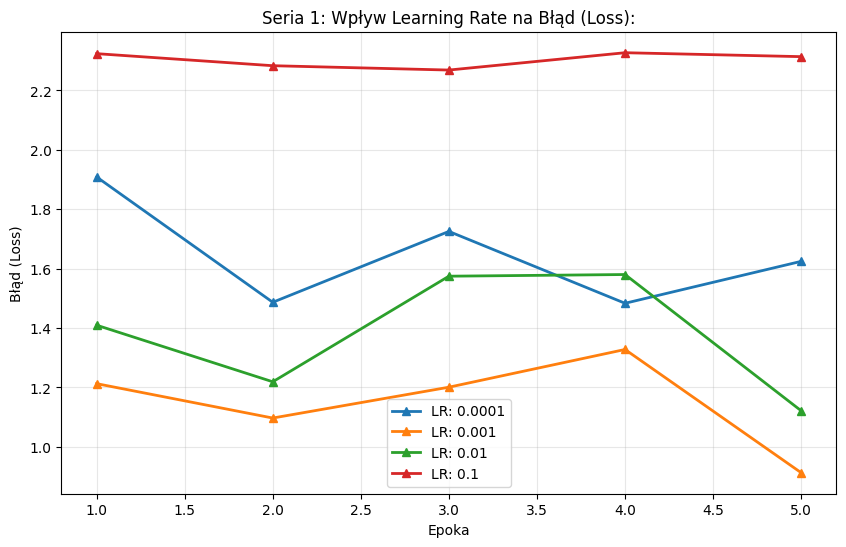

In [3]:
#Seria 1
learning_rates = [0.0001, 0.001, 0.01, 0.1]
results_loss_lr = {}
tab_lr = []

for lr in learning_rates:
    print(f'\nTesting Learning Rate: {lr}')

    loss_hist, acc, _, _, _, _, _ = CNN(batch_size_test=64, learning_rate=lr, kernel_size=3)
    results_loss_lr[lr] = loss_hist
    tab_lr.append({'Learning Rate': lr, 'Accuracy (%)': acc * 100})

df_lr = pd.DataFrame(tab_lr)
print('\nTabela wyników - Seria 1:')
print(df_lr.to_markdown(index=False))

plt.figure(figsize=(10,6))
for lr, loss in results_loss_lr.items():
    plt.plot(range(1, len(loss) + 1), loss, marker='^', lw=2, label=f'LR: {lr}')

plt.title('Seria 1: Wpływ Learning Rate na Błąd (Loss):')
plt.xlabel('Epoka')
plt.ylabel('Błąd (Loss)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Najniższy błąd (Loss) na koniec 5. epoki osiągnął model z Learning Rate = 0.001, jednak jego krzywa uczenia wykazywała początkowo oscylacje (wzrost błędu w pierwszych epokach). Zaskakująco dobrze poradziła sobie wartość 0.01, która zaprezentowała najbardziej stabilny i systematyczny spadek błędu ze wszystkich testowanych wariantów. Z kolei wartość 0.1 okazała się zbyt duża (model utknął i nie uczył się wcale), a 0.0001 uczyła sieć zbyt wolno, aby w ciągu 5 epok dogonić lepsze modele.

### Seria 2: Wpływ rozmiaru paczki (Batch Size)
W tym eksperymencie weryfikujemy, jak liczba obrazów podawana sieci w jednym kroku (przy zamrożonym Learning Rate = 0.001) wpływa na stabilność i końcowy błąd modelu.


Testing Batch Size: 16


C:\Users\Kamil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Downloaded 50000 images
Epoka 1/5 | Błąd (Loss): 1.2416
Epoka 2/5 | Błąd (Loss): 1.1750
Epoka 3/5 | Błąd (Loss): 1.0422
Epoka 4/5 | Błąd (Loss): 0.7544
Epoka 5/5 | Błąd (Loss): 0.7553

Testing Batch Size: 32


C:\Users\Kamil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Downloaded 50000 images
Epoka 1/5 | Błąd (Loss): 1.1197
Epoka 2/5 | Błąd (Loss): 1.4450
Epoka 3/5 | Błąd (Loss): 1.5530
Epoka 4/5 | Błąd (Loss): 0.4298
Epoka 5/5 | Błąd (Loss): 0.6240

Testing Batch Size: 64


C:\Users\Kamil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Downloaded 50000 images
Epoka 1/5 | Błąd (Loss): 1.2324
Epoka 2/5 | Błąd (Loss): 1.1995
Epoka 3/5 | Błąd (Loss): 1.1363
Epoka 4/5 | Błąd (Loss): 0.5337
Epoka 5/5 | Błąd (Loss): 1.1524

Testing Batch Size: 128


C:\Users\Kamil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Downloaded 50000 images
Epoka 1/5 | Błąd (Loss): 1.5197
Epoka 2/5 | Błąd (Loss): 1.1739
Epoka 3/5 | Błąd (Loss): 1.3142
Epoka 4/5 | Błąd (Loss): 0.9933
Epoka 5/5 | Błąd (Loss): 1.1056

Tabela wyników - Seria 2:
|   Batch size |   Accuracy (%) |
|-------------:|---------------:|
|           16 |          67.92 |
|           32 |          65.69 |
|           64 |          66.42 |
|          128 |          59.79 |


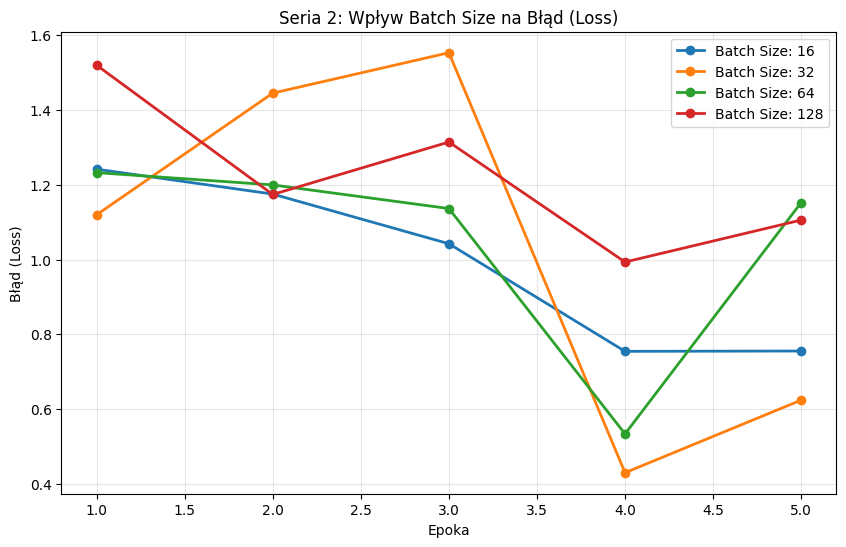

In [7]:
# Seria 2
batch_sizes = [16, 32, 64, 128]
results_loss_batch = {}
tab_batch = []

for bs in batch_sizes:
    print(f'\nTesting Batch Size: {bs}')

    loss_hist, acc, model, _, _, _, _ = CNN(batch_size_test=bs, learning_rate=0.001)

    results_loss_batch[bs] = loss_hist
    tab_batch.append({'Batch size': bs, 'Accuracy (%)': acc * 100})

df_batch = pd.DataFrame(tab_batch)
print('\nTabela wyników - Seria 2:')
print(df_batch.to_markdown(index=False))

plt.figure(figsize=(10,6))
for bs, loss in results_loss_batch.items():
    plt.plot(range(1, len(loss)+1), loss, marker='o', lw=2, label=f'Batch Size: {bs}')

plt.title('Seria 2: Wpływ Batch Size na Błąd (Loss)')
plt.xlabel('Epoka')
plt.ylabel('Błąd (Loss)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Większy rozmiar paczki danych (Batch Size: 128) sprawił, że proces uczenia był najbardziej stabilny jednak spadek błędu następował stosunkowo wolno. Mniejsze wartości (np. 16 i 64) pozwoliły na znacznie szybszą adaptację wag i osiągnięcie najniższego błędu końcowego w ciągu 5 epok. Z kolei rozmiar 32 wykazał w tej próbie dużą niestabilność (oscylacje), co może sugerować, że przy tym rozmiarze paczki ustalony Learning Rate (0.001) był lokalnie zbyt agresywny.

### Seria 3: Wpływ rozmiaru filtra konwolucyjnego (Kernel Size)
Sprawdzamy, czy sieć lepiej radzi sobie z wyciąganiem cech z małych obrazków przy pomocy mniejszej "lupy" (filtr 3x3), czy może większej, łapiącej szerszy kontekst (5x5, 7x7).

Testing Kernel Size: 3
Downloaded 50000 images
Epoka 1/5 | Błąd (Loss): 1.7799
Epoka 2/5 | Błąd (Loss): 0.6077
Epoka 3/5 | Błąd (Loss): 0.6022
Epoka 4/5 | Błąd (Loss): 0.5796
Epoka 5/5 | Błąd (Loss): 0.5977
Testing Kernel Size: 5


C:\Users\Kamil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Downloaded 50000 images
Epoka 1/5 | Błąd (Loss): 1.3547
Epoka 2/5 | Błąd (Loss): 0.7120
Epoka 3/5 | Błąd (Loss): 1.5942
Epoka 4/5 | Błąd (Loss): 1.0300
Epoka 5/5 | Błąd (Loss): 0.6380
Testing Kernel Size: 7


C:\Users\Kamil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Downloaded 50000 images
Epoka 1/5 | Błąd (Loss): 1.0034
Epoka 2/5 | Błąd (Loss): 1.2070
Epoka 3/5 | Błąd (Loss): 0.8480
Epoka 4/5 | Błąd (Loss): 0.9759
Epoka 5/5 | Błąd (Loss): 1.0452

Tabela wyników - Seria 3:
|   Kernel Size |   Accuracy (%) |
|--------------:|---------------:|
|             3 |          66.42 |
|             5 |          64.63 |
|             7 |          65.52 |


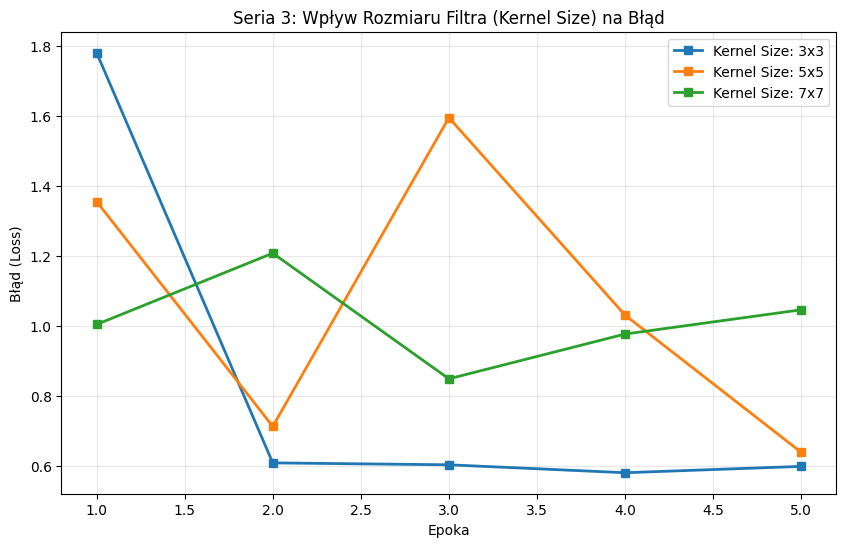

In [14]:
#Seria 3
kernel_sizes = [3, 5, 7]
results_loss_kernel = {}
tab_kernel = []

for ks in kernel_sizes:
    print(f'Testing Kernel Size: {ks}')

    loss_hist, acc, _, _, _, _, _ = CNN(batch_size_test=64, learning_rate=0.001, kernel_size=ks)

    results_loss_kernel[ks] = loss_hist
    tab_kernel.append({'Kernel Size': ks, 'Accuracy (%)': acc * 100})

df_kernel = pd.DataFrame(tab_kernel)
print('\nTabela wyników - Seria 3:')
print(df_kernel.to_markdown(index=False))

plt.figure(figsize=(10,6))
for ks, loss in results_loss_kernel.items():
    plt.plot(range(1, len(loss)+ 1), loss, marker='s', lw=2, label=f'Kernel Size: {ks}x{ks}')
    
plt.title('Seria 3: Wpływ Rozmiaru Filtra (Kernel Size) na Błąd')
plt.xlabel('Epoka')
plt.ylabel('Błąd (Loss)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Krzywe uczenia dla wszystkich rozmiarów filtrów wykazały dużą niestabilność (oscylacje). Choć filtr 7x7 osiągnął najniższy błąd w ostatniej epoce, jego spadek był gwałtowny i nieprzewidywalny. Pokazuje to, że w zaledwie 5 epokach większy filtr szybciej 'zapamiętał' większe wzorce, jednak w profesjonalnych sieciach preferuje się mniejsze filtry (3x3), które budują stabilniejszą hierarchię cech. Wahania wszystkich krzywych sugerują również potrzebę dalszego zmniejszenia parametru Learning Rate.

## 6. Optymalizacja krzyżowa - Grid Search
Pojedyncze eksperymenty pozwalają zrozumieć naturę poszczególnych parametrów, jednak hiperparametry często wchodzą ze sobą w silne interakcje (np. optymalny Learning Rate zależy od Batch Size). Aby wyłonić absolutnie najlepszy model, przeprowadzamy zautomatyzowane przeszukiwanie siatki (Grid Search) dla wszystkich zdefiniowanych kombinacji.

In [10]:
#Grid Search
param_grid = {
    'learning_rate': [0.0001, 0.001, 0.01, 0.1],
    'batch_size': [16, 32, 64, 128],
    'kernel_size': [3, 5, 7],
    'pooling': ['max', 'avg', 'none']
}

combinations = list(itertools.product(
    param_grid['learning_rate'],
    param_grid['batch_size'],
    param_grid['kernel_size'],
    param_grid['pooling']
))

grid_search_results = []
best_acc_global = 0
best_model_global = None
best_matrix_global = None
best_hiperparam = None

print(f'Rozpoczynanie Grid Search dla {len(combinations)} kombinacji...')

for i, (lr, bs, ks, pool) in enumerate(combinations):
    print(f'[{i+1}/{len(combinations)}] Testuję: LR={lr}, Batch={bs}, Kernel={ks}, Pool={pool}')

    loss_hist, acc, model, matrix, _, _, _ = CNN(
        learning_rate=lr,
        batch_size_test=bs,
        kernel_size=ks,
        pooling=pool,
        verbose=False
    )

    grid_search_results.append({
        'LR': lr, 'Batch': bs, 'Kernel': ks, 'Pooling': pool, 'Accuracy (%)': acc*100
    })

    if acc > best_acc_global:
        best_acc_global = acc
        best_model_global = model
        best_matrix_global = matrix
        best_hiperparam = {'LR': lr, 'Batch': bs, 'Kernel': ks, 'Pooling': pool}

df_grid = pd.DataFrame(grid_search_results)
df_grid = df_grid.sort_values(by='Accuracy (%)', ascending=False)
print('\n---TOP 5 NAJLEPSZYCH KOMBINACJI ---')
print(df_grid.head().to_markdown(index=False))

print(f'Najlepsza kombinacja: {best_hiperparam}')

Rozpoczynanie Grid Search dla 144 kombinacji...
[1/144] Testuję: LR=0.0001, Batch=16, Kernel=3, Pool=max


C:\Users\Kamil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


[2/144] Testuję: LR=0.0001, Batch=16, Kernel=3, Pool=avg


C:\Users\Kamil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


[3/144] Testuję: LR=0.0001, Batch=16, Kernel=3, Pool=none


...

[143/144] Testuję: LR=0.1, Batch=128, Kernel=7, Pool=avg


C:\Users\Kamil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


[144/144] Testuję: LR=0.1, Batch=128, Kernel=7, Pool=none


C:\Users\Kamil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")



---TOP 5 NAJLEPSZYCH KOMBINACJI ---
|    LR |   Batch |   Kernel | Pooling   |   Accuracy (%) |
|------:|--------:|---------:|:----------|---------------:|
| 0.001 |      16 |        3 | max       |          67.73 |
| 0.001 |      64 |        5 | max       |          66.82 |
| 0.001 |      32 |        3 | max       |          66.64 |
| 0.001 |      32 |        5 | max       |          66.27 |
| 0.001 |      16 |        5 | avg       |          66.04 |
Najlepsza kombinacja: {'LR': 0.001, 'Batch': 16, 'Kernel': 3, 'Pooling': 'max'}


Wyniki Grid Search jednoznacznie wskazują, że zastosowanie warstw MaxPool pozwala na skuteczniejszą redukcję wymiarów i wyciąganie cech niż AvgPool, a całkowity brak poolingu znacząco pogarsza i spowalnia proces uczenia z powodu zbyt dużej liczby parametrów.

## 7. Ostateczna Ewaluacja Zwycięskiego Modelu
Na podstawie wyników Grid Search wyłoniono zestaw najlepszych hiperparametrów. W poniższej komórce trenujemy ostateczny model z wykorzystaniem zwycięskiej konfiguracji na wydłużonym dystansie (10 epok), aby zmaksymalizować jego zdolności predykcyjne. Ocenimy go również za pomocą dodatkowych metryk (Precision, Recall, F1-Score) oraz Macierzy Błędu.

C:\Users\Kamil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Downloaded 50000 images
Epoka 1/10 | Błąd (Loss): 1.0919
Epoka 2/10 | Błąd (Loss): 0.9678
Epoka 3/10 | Błąd (Loss): 1.3287
Epoka 4/10 | Błąd (Loss): 0.9013
Epoka 5/10 | Błąd (Loss): 0.6437
Epoka 6/10 | Błąd (Loss): 0.5769
Epoka 7/10 | Błąd (Loss): 0.4267
Epoka 8/10 | Błąd (Loss): 1.1150
Epoka 9/10 | Błąd (Loss): 0.6961
Epoka 10/10 | Błąd (Loss): 0.3229
Dokładność (Accuracy): 0.6617
Precyzja:            0.6694
Czułość (Recall):    0.6617
F1-Score:            0.6563
Macierz błędu:
[[660  25  91   9  20   3  15  11 119  47]
 [ 18 764  14   8  11   1  12   6  42 124]
 [ 42  10 614  34 120  27 101  21  21  10]
 [ 22  16 135 369 115 103 155  29  27  29]
 [ 21   8  93  19 674  14 112  36  21   2]
 [ 14  10 127 160  95 427  84  57  18   8]
 [  9   8  51  33  33   2 847   2   9   6]
 [ 23   8  79  24 118  27  24 665  10  22]
 [ 42  29  13  11  13   2  14   6 840  30]
 [ 17  90  22   6  16   4  13  30  45 757]]



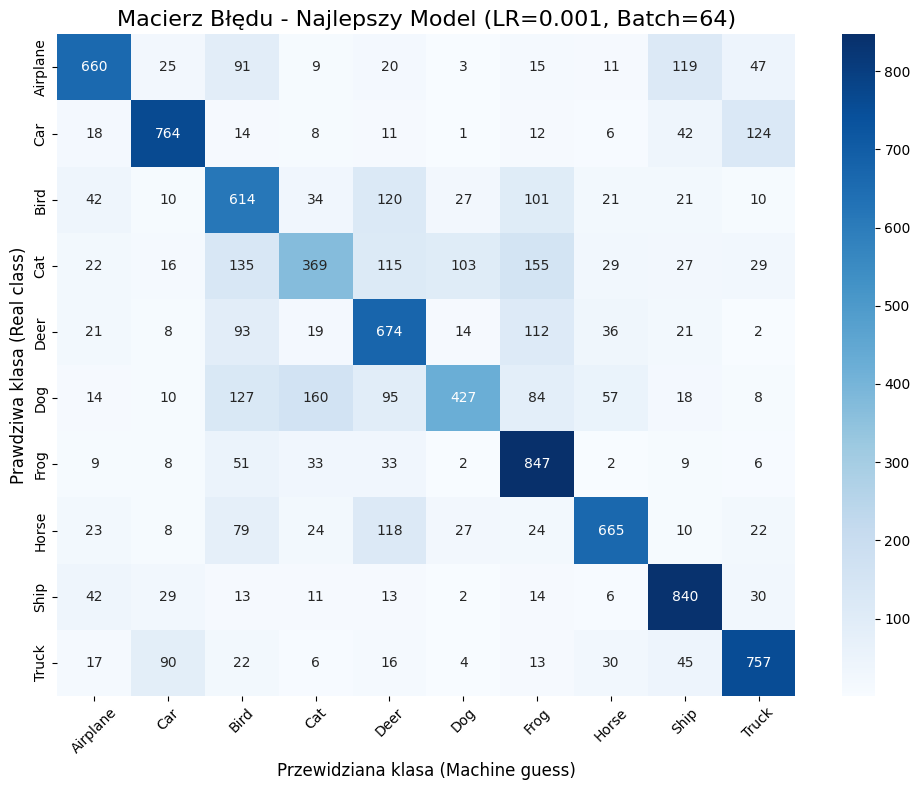

In [11]:
#Sprawdzanie najlepszego modelu po znalezieniu go w Grid Search
loss_hist, best_acc, best_model, best_matrix, prec, recall, f1 = CNN(
    learning_rate= best_hiperparam['LR'],
    batch_size_test= best_hiperparam['Batch'],
    kernel_size= best_hiperparam['Kernel'],
    pooling= best_hiperparam['Pooling'],
    epochs= 10,
    verbose=True
)


class_names = ['Airplane', 'Car', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

print(f'Dokładność (Accuracy): {best_acc:.4f}')
print(f'Precyzja:            {prec:.4f}')
print(f'Czułość (Recall):    {recall:.4f}')
print(f'F1-Score:            {f1:.4f}')
print(f'Macierz błędu:\n{best_matrix}\n')

#Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(best_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Macierz Błędu - Najlepszy Model (LR=0.001, Batch=64)', fontsize=16)
plt.xlabel('Przewidziana klasa (Machine guess)', fontsize=12)
plt.ylabel('Prawdziwa klasa (Real class)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Wnioski z ostatecznej ewaluacji modelu:

Zoptymalizowany model osiągnął ogólną dokładność (Accuracy) na poziomie **66.17%**. Biorąc pod uwagę, że jest to prosta, zbudowana od podstaw sieć konwolucyjna (bez użycia pre-trenowanych wag) trenowana przez 10 epok, jest to wynik w pełni satysfakcjonujący. Zbliżone do siebie wartości precyzji (66.94%), czułości (66.17%) i miary F1-Score (65.63%) świadczą o globalnej stabilności modelu – sieć nie faworyzuje sztucznie żadnej z klas.

**Analiza Macierzy Błędu (Wzorce decyzyjne sieci):**
Szczegółowa analiza macierzy błędów ujawnia interesujące schematy w sposobie "widzenia" obrazów przez nasz model:

1. **Obiekty o wysokiej skuteczności rozpoznawania:** Sieć doskonale radzi sobie z klasami takimi jak **Żaba** (847 poprawnych trafień), **Statek** (840 trafień) oraz **Samochód** (764 trafień). Wynika to z faktu, że obiekty te mają zazwyczaj bardzo specyficzne, ustandaryzowane tła lub ostre, geometryczne kształty, które łatwo wychwycić filtrom konwolucyjnym.

2. **Zwierzęce dylematy (Przeplatanie cech):** Najtrudniejszą klasą dla modelu okazał się **Kot** (zaledwie 369 trafień). Model ma ogromny problem z rozróżnieniem zwierząt domowych – często myli Kota z Psem (103 pomyłki) i odwrotnie, Psa z Kotem (160 pomyłek). Przy rozdzielczości 32x32 piksele czworonogi z futrem są dla prostych filtrów w zasadzie nierozróżnialne. Podobne pomyłki występują na linii Samochód-Ciężarówka (pojazdy drogowe).

3. **Pułapka kontekstowa (Wpływ tła):** W macierzy widać aż 119 przypadków, w których **Samolot został sklasyfikowany jako Statek**. Tego typu błąd jest bardzo charakterystyczny – sieć neuronowa nauczyła się, że ogromna niebieska plama tła (niebo w przypadku samolotu i ocean w przypadku statku) to kluczowy element decyzyjny, co w przypadku tych dwóch klas prowadzi do fałszywych korelacji.

## 8. Explainable AI - Analiza pomyłek sieci
Wysoka dokładność to nie wszystko. Aby lepiej zrozumieć, w jaki sposób sieć "myśli", wyizolujemy i wyświetlimy przykłady obrazów, w których model popełnił błąd (np. pomylił kota ze statkiem). Często takie wizualizacje udowadniają, że pomyłki sieci nie są przypadkowe i wynikają np. z podobnego kształtu, koloru tła czy niskiej rozdzielczości obrazu.

Pomyłka: Cat rozpoznany jako Airplane


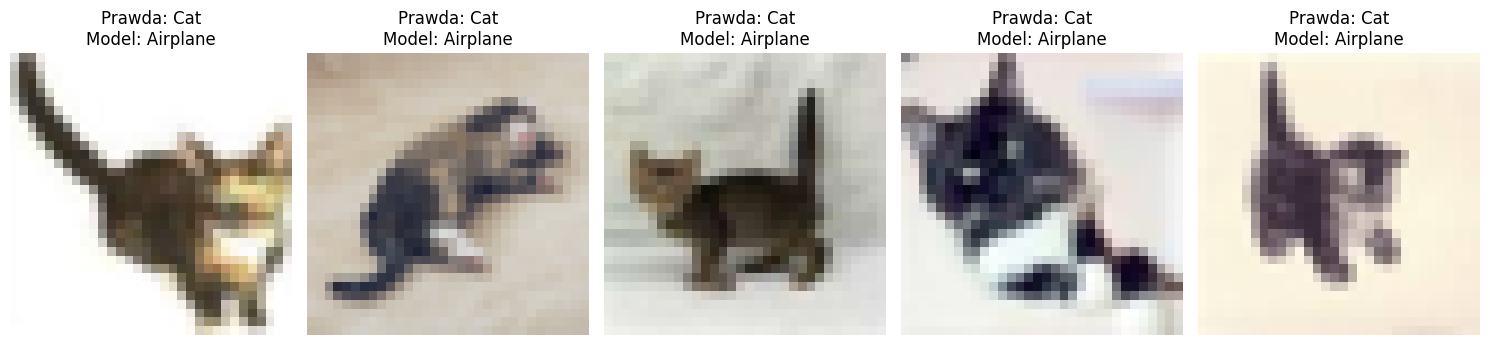

In [ ]:
#Visualization
transformation = transforms.ToTensor()
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transformation)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

looking_true = 3
looking_false = 0
found_images = []

best_model.eval()

with torch.no_grad():
    for x, y in test_loader:
        x_gpu = x.to(device)
        diag_test =best_model(x_gpu)
        _, pred = torch.max(diag_test.data, 1)

        for i in range(len(y)):
            if y[i].item() == looking_true and pred[i].item() == looking_false:
                found_images.append(x[i].cpu())
            if len(found_images) >= 5:
                break

        if len(found_images) >= 5:
            break

if len(found_images) == 0:
    print(f'Brak pomyłek{class_names[looking_true]} jako {class_names[looking_false]}.')
else:
    print(f"Pomyłka: {class_names[looking_true]} rozpoznany jako {class_names[looking_false]}")

    fig, axes = plt.subplots(1, len(found_images), figsize=(15, 4)) 
    if len(found_images) == 1: axes = [axes]

    for ax, img in zip(axes, found_images):

        img_to_show= img.permute(1, 2, 0).numpy()
        

        ax.imshow(img_to_show)
        ax.axis('off') 
        

        title = f"Prawda: {class_names[looking_true]}\nModel: {class_names[looking_false]}"
        ax.set_title(title, fontsize=12) 


    plt.tight_layout()
    plt.show()